# MTL-GRU — 4-task full-200 SOH-weight sweep

This notebook is derived from the previous **MTL-GRU 4-task full-200** notebook.  
The backbone, data handling, masks, scaler inversion, optimizer, five seeds, and 200-epoch protocol are kept unchanged.

## What changes in this experiment

Only the **task-level loss weights** are changed.

The three new candidate settings are:

| config | SOH | R0 | R1 | R2 |
|---|---:|---:|---:|---:|
| `soh40` | 0.40 | 0.20 | 0.20 | 0.20 |
| `soh50` | 0.50 | 1/6 | 1/6 | 1/6 |
| `soh60` | 0.60 | 0.40/3 | 0.40/3 | 0.40/3 |

The old equal-weight `0.25 / 0.25 / 0.25 / 0.25` run is **not retrained by default**. Its frozen validation losses at the joint-best checkpoint are embedded below and are used only as a validation reference.

## Important methodological rule

This notebook is intentionally split into two stages.

### Stage A — weight sweep, validation only
1. Train every candidate for the full 200 epochs and all five seeds.
2. Use the **same weights** for:
   - the training objective;
   - the validation joint loss;
   - the primary joint-best checkpoint selection.
3. Compare candidate weights using **validation data only**.
4. Do **not** inspect test performance for every candidate.

### Stage B — final test
After one weight setting has been fixed from Stage A, set `FINAL_CONFIG` to that config name and run the final evaluation cells.  
Only that frozen config is evaluated on test.

R0/R1/R2 still average their three SOC channels equally inside each task.  
The task-weight sweep therefore changes only the balance among SOH/R0/R1/R2.

In [1]:
import sys
import torch
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: d:\venvs\torch_test\Scripts\python.exe
PyTorch: 2.8.0+cpu
NumPy: 2.5.3
Pandas: 3.0.5


In [2]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEEDS = [42, 43, 44, 45, 46]
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
print('seeds:', SEEDS)

# Keep the original full-200 backbone / hyperparameters unchanged.
HID          = 64
ENC_LAYERS   = 1
DROPOUT      = 0.2
LR           = 3e-3
WEIGHT_DECAY = 1e-4
EPOCHS       = 200
BATCH_SIZE   = 32
TRAIN_EVAL_BATCH = 256

# ------------------------------------------------------------
# Stage control
# ------------------------------------------------------------
# First pass:
#   RUN_SWEEP = True
#   FINAL_CONFIG = None
#
# After the validation-only weight decision:
#   RUN_SWEEP = False
#   FINAL_CONFIG = 'soh40' / 'soh50' / 'soh60'
#
# With RUN_SWEEP=False, the notebook reloads the saved sweep CSVs and
# does not retrain. Final evaluation then loads the saved checkpoints.
RUN_SWEEP = True
FINAL_CONFIG = None

TASK_ORDER = ['SOH', 'R0', 'R1', 'R2']

WEIGHT_CONFIGS = {
    'soh40': {'SOH': 0.40, 'R0': 0.20,       'R1': 0.20,       'R2': 0.20},
    'soh50': {'SOH': 0.50, 'R0': 1.0 / 6.0,  'R1': 1.0 / 6.0,  'R2': 1.0 / 6.0},
    'soh60': {'SOH': 0.60, 'R0': 0.40 / 3.0, 'R1': 0.40 / 3.0, 'R2': 0.40 / 3.0},
}

for name, w in WEIGHT_CONFIGS.items():
    assert list(w.keys()) == TASK_ORDER
    assert all(v > 0 for v in w.values())
    assert abs(sum(w.values()) - 1.0) < 1e-12
    print(name, {k: round(v, 6) for k, v in w.items()})

SWEEP_PREFIX = 'mtl_gru_4task_full200_weight_sweep'
CKPT_ROOT = Path(f'{SWEEP_PREFIX}_checkpoints')
CKPT_ROOT.mkdir(parents=True, exist_ok=True)

device: cpu
seeds: [42, 43, 44, 45, 46]
soh40 {'SOH': 0.4, 'R0': 0.2, 'R1': 0.2, 'R2': 0.2}
soh50 {'SOH': 0.5, 'R0': 0.166667, 'R1': 0.166667, 'R2': 0.166667}
soh60 {'SOH': 0.6, 'R0': 0.133333, 'R1': 0.133333, 'R2': 0.133333}


In [3]:
# ---- load data + scaler ----
DATA_CANDIDATES   = [Path('seq_dataset_10dim_v7.npz'), Path('/mnt/data/seq_dataset_10dim_v7.npz')]
SCALER_CANDIDATES = [Path('scaler_10dim_v7.json'),     Path('/mnt/data/scaler_10dim_v7.json')]
DATA_PATH   = next((p for p in DATA_CANDIDATES if p.exists()), None)
SCALER_PATH = next((p for p in SCALER_CANDIDATES if p.exists()), None)

if DATA_PATH is None or SCALER_PATH is None:
    raise FileNotFoundError(
        '请把 seq_dataset_10dim_v7.npz 和 scaler_10dim_v7.json 放到同目录或 /mnt/data/。'
    )

data = np.load(DATA_PATH, allow_pickle=True)
features = data['features'].tolist()
F = len(features)

cfg = json.load(open(SCALER_PATH, encoding='utf-8'))
assert cfg['features'] == features, 'scaler 与数据集特征顺序不一致'
assert bool(cfg.get('log_r', False)), '当前 MTL 物理还原要求 scaler 中 log_r=True'

MEAN = np.asarray(cfg['mean'], dtype=float)
STD  = np.asarray(cfg['std'], dtype=float)
R_COLS = set(cfg['r_cols'])

# ---- four-task definition: 1 + 3 + 3 + 3 = 10 output channels ----
TASK_CHANNELS = {
    'SOH': [features.index('SOH')],
    'R0':  [features.index('SOC10_R0'), features.index('SOC50_R0'), features.index('SOC90_R0')],
    'R1':  [features.index('SOC10_R1'), features.index('SOC50_R1'), features.index('SOC90_R1')],
    'R2':  [features.index('SOC10_R2'), features.index('SOC50_R2'), features.index('SOC90_R2')],
}
TASK_DIMS = {task: len(idxs) for task, idxs in TASK_CHANNELS.items()}

assert list(TASK_CHANNELS.keys()) == TASK_ORDER
assert sum(TASK_DIMS.values()) == F == 10
assert set(sum(TASK_CHANNELS.values(), [])) == set(range(F))

FEATURE_TO_TASK = {
    features[j]: task
    for task, idxs in TASK_CHANNELS.items()
    for j in idxs
}

def inverse_feature(z, feature_idx):
    """Inverse standardized feature to its physical/original scale."""
    x = np.asarray(z, dtype=float) * STD[feature_idx] + MEAN[feature_idx]
    if features[feature_idx] in R_COLS:
        return np.expm1(x)        # preprocessing confirmed: log1p(R)
    return x                      # SOH: affine inverse only

def get(split):
    # Keep exactly the same input handling as the previous STL/MTL notebooks.
    X = np.where(
        data[f'{split}_X_fmask'].astype(bool),
        data[f'{split}_X'].astype(np.float32),
        0.0
    )
    Xt = data[f'{split}_X_tmask'].astype(bool)

    Y = data[f'{split}_Y'].astype(np.float32)
    Ym = data[f'{split}_Y_mask'].astype(bool)
    bid = data[f'{split}_bid']
    return X.astype(np.float32), Xt, Y, Ym, bid

Xtr, Xttr, Ytr, Ymtr, btr = get('train')
Xva, Xtva, Yva, Ymva, bva = get('val')
Xte, Xtte, Yte, Ymte, bte = get('test')
HORIZON = Ytr.shape[1]

utr, uva, ute = np.unique(btr), np.unique(bva), np.unique(bte)

print('features:', features)
print('task channels:', {k: [features[j] for j in v] for k, v in TASK_CHANNELS.items()})
print('sample/window counts:',
      'train=', len(btr), 'val=', len(bva), 'test=', len(bte))
print('unique battery counts:',
      'train=', len(utr), 'val=', len(uva), 'test=', len(ute))
print('max forecast horizon:', HORIZON)

assert np.intersect1d(utr, uva).size == 0, 'Leakage: train and val share battery IDs'
assert np.intersect1d(utr, ute).size == 0, 'Leakage: train and test share battery IDs'
assert np.intersect1d(uva, ute).size == 0, 'Leakage: val and test share battery IDs'

print('Battery leakage check passed.')

# ---------------------------------------------------------------------
# Frozen equal-weight MTL validation reference
# ---------------------------------------------------------------------
# These are the per-seed validation task MSEs at the joint-best checkpoint
# from the already-completed equal-weight full-200 run.
#
# They are VALIDATION values only. No frozen test metric is used below to
# choose a task-weight configuration.
FROZEN_EQUAL_VAL_BY_SEED = pd.DataFrame([
    {'seed': 42, 'SOH': 0.044011447364830175, 'R0': 0.38749302528035656, 'R1': 0.3070050019848068,  'R2': 0.3136505149961217},
    {'seed': 43, 'SOH': 0.04018367813433045,  'R0': 0.33929897378719653, 'R1': 0.29926744210128337, 'R2': 0.31680448833390323},
    {'seed': 44, 'SOH': 0.04710041864400904,  'R0': 0.40884126755478184, 'R1': 0.2970211384537325,  'R2': 0.294179553984624},
    {'seed': 45, 'SOH': 0.035052699985100785, 'R0': 0.46350110767197994, 'R1': 0.31049362628576976, 'R2': 0.27787299386184455},
    {'seed': 46, 'SOH': 0.048972507257836105, 'R0': 0.40756932018562114, 'R1': 0.334191896256697,   'R2': 0.3237714969077709},
])

assert FROZEN_EQUAL_VAL_BY_SEED['seed'].tolist() == SEEDS
display(FROZEN_EQUAL_VAL_BY_SEED.round(6))

features: ['SOH', 'SOC10_R0', 'SOC50_R0', 'SOC90_R0', 'SOC10_R1', 'SOC50_R1', 'SOC90_R1', 'SOC10_R2', 'SOC50_R2', 'SOC90_R2']
task channels: {'SOH': ['SOH'], 'R0': ['SOC10_R0', 'SOC50_R0', 'SOC90_R0'], 'R1': ['SOC10_R1', 'SOC50_R1', 'SOC90_R1'], 'R2': ['SOC10_R2', 'SOC50_R2', 'SOC90_R2']}
sample/window counts: train= 4581 val= 45 test= 45
unique battery counts: train= 212 val= 45 test= 45
max forecast horizon: 29
Battery leakage check passed.


,seed,SOH,R0,R1,R2
0,42,0.044011,0.387493,0.307005,0.313651
1,43,0.040184,0.339299,0.299267,0.316804
2,44,0.047100,0.408841,0.297021,0.294180
3,45,0.035053,0.463501,0.310494,0.277873
4,46,0.048973,0.407569,0.334192,0.323771


In [4]:
# ---- MTL model: SAME shared encoder + shared decoder, FOUR output heads ----
class MTLGRUSeq2Seq(nn.Module):
    def __init__(self, in_dim, hid=64, layers=1, task_dims=None, horizon=29, p=0.2):
        super().__init__()
        if task_dims is None:
            task_dims = {'SOH': 1, 'R0': 3, 'R1': 3, 'R2': 3}

        self.encoder = nn.GRU(
            in_dim, hid, layers,
            batch_first=True,
            dropout=p if layers > 1 else 0.0
        )
        self.dec_cell = nn.GRUCell(hid, hid)
        self.drop = nn.Dropout(p)

        self.heads = nn.ModuleDict({
            task: nn.Linear(hid, out_dim)
            for task, out_dim in task_dims.items()
        })
        self.horizon = horizon

    def forward(self, x, x_tmask):
        lengths = x_tmask.sum(1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths,
            batch_first=True,
            enforce_sorted=False
        )
        _, h = self.encoder(packed)
        s = h[-1]
        z = torch.zeros_like(s)

        outs = {task: [] for task in self.heads}

        for _ in range(self.horizon):
            s = self.dec_cell(z, s)
            sd = self.drop(s)
            for task, head in self.heads.items():
                outs[task].append(head(sd).unsqueeze(1))
            z = s

        return {
            task: torch.cat(parts, dim=1)
            for task, parts in outs.items()
        }

def equal_channel_masked_mse(pred, target, mask):
    """
    pred/target/mask: (B, H, C)

    Each channel is normalized by its own number of valid targets first,
    then valid channels are equally averaged.
    """
    m = mask.float()
    sq_sum = (((pred - target) ** 2) * m).sum(dim=(0, 1))
    n_valid = m.sum(dim=(0, 1))
    active = n_valid > 0

    if not torch.any(active):
        return None

    channel_mse = sq_sum[active] / n_valid[active]
    return channel_mse.mean()

def weighted_active_task_mean(losses, task_weights):
    """
    Weighted mean across the tasks that are active in the current batch.

    If a task has no valid target in a particular batch, the remaining
    task weights are renormalized so their active weights sum to 1.
    """
    active_tasks = [
        task for task in TASK_ORDER
        if losses.get(task) is not None
    ]
    if not active_tasks:
        raise RuntimeError('No valid targets in this batch.')

    active_weight_sum = sum(float(task_weights[t]) for t in active_tasks)
    if active_weight_sum <= 0:
        raise RuntimeError('Active task-weight sum must be positive.')

    terms = [
        losses[t] * (float(task_weights[t]) / active_weight_sum)
        for t in active_tasks
    ]
    return torch.stack(terms).sum()

def multitask_loss(outputs, y, ym, task_weights):
    """
    Weighted 4-task loss:

        total = w_SOH * SOH
              + w_R0  * R0
              + w_R1  * R1
              + w_R2  * R2

    R0/R1/R2 internally average their three SOC channel losses equally.
    """
    losses = {}

    for task, idxs in TASK_CHANNELS.items():
        target = y[:, :, idxs]
        mask = ym[:, :, idxs]
        losses[task] = equal_channel_masked_mse(
            outputs[task],
            target,
            mask
        )

    total = weighted_active_task_mean(losses, task_weights)
    return total, losses


START CONFIG: soh40 {'SOH': 0.4, 'R0': 0.2, 'R1': 0.2, 'R2': 0.2}
config=soh40 | seed=42 | epoch=  1/200 | weighted val=0.494146 | unweighted val=0.570386 | SOH=0.189185 | R0=0.792877 | R1=0.708117 | R2=0.591366 | best weighted joint=0.494146 @ 1
config=soh40 | seed=42 | epoch= 20/200 | weighted val=0.252494 | unweighted val=0.300724 | SOH=0.059572 | R0=0.464779 | R1=0.356755 | R2=0.321791 | best weighted joint=0.252298 @ 18
config=soh40 | seed=42 | epoch= 40/200 | weighted val=0.247512 | unweighted val=0.294615 | SOH=0.059102 | R0=0.436224 | R1=0.355396 | R2=0.327738 | best weighted joint=0.230744 @ 37
config=soh40 | seed=42 | epoch= 60/200 | weighted val=0.238995 | unweighted val=0.286033 | SOH=0.050844 | R0=0.440404 | R1=0.323713 | R2=0.329170 | best weighted joint=0.230744 @ 37
config=soh40 | seed=42 | epoch= 80/200 | weighted val=0.237063 | unweighted val=0.282899 | SOH=0.053722 | R0=0.433754 | R1=0.321550 | R2=0.322570 | best weighted joint=0.230744 @ 37
config=soh40 | seed=42 |

,weight_config,seed,w_SOH,w_R0,w_R1,w_R2,best_val_joint_MSE_std,best_val_weighted_joint_MSE_std,best_val_unweighted_joint_MSE_std_at_joint_ckpt,best_joint_epoch,...,joint_ckpt_val_R1_MSE_std,joint_ckpt_val_R2_MSE_std,best_val_SOH_MSE_std_diagnostic,best_SOH_epoch_diagnostic,best_val_R0_MSE_std_diagnostic,best_R0_epoch_diagnostic,best_val_R1_MSE_std_diagnostic,best_R1_epoch_diagnostic,best_val_R2_MSE_std_diagnostic,best_R2_epoch_diagnostic
0,soh40,42,0.4,0.200000,0.200000,0.200000,0.223374,0.223374,0.267788,106,...,0.320034,0.309035,0.031465,116,0.396369,106,0.307071,46,0.267787,116
1,soh40,43,0.4,0.200000,0.200000,0.200000,0.205322,0.205322,0.249462,47,...,0.289320,0.268875,0.025064,178,0.398744,40,0.289320,47,0.250698,128
2,soh40,44,0.4,0.200000,0.200000,0.200000,0.233477,0.233477,0.279147,12,...,0.314832,0.342661,0.036110,188,0.407568,21,0.314319,36,0.277495,188
3,soh40,45,0.4,0.200000,0.200000,0.200000,0.222814,0.222814,0.265965,23,...,0.303503,0.310301,0.031492,133,0.366508,179,0.303503,23,0.277784,198
4,soh40,46,0.4,0.200000,0.200000,0.200000,0.236193,0.236193,0.285224,35,...,0.363813,0.309474,0.036956,147,0.410287,94,0.326645,11,0.288038,147
5,soh50,42,0.5,0.166667,0.166667,0.166667,0.185557,0.185557,0.258869,125,...,0.299657,0.298740,0.033003,35,0.391093,190,0.299657,125,0.273281,165
6,soh50,43,0.5,0.166667,0.166667,0.166667,0.180646,0.180646,0.251791,64,...,0.290539,0.305985,0.033210,135,0.361136,146,0.290539,64,0.278881,135
7,soh50,44,0.5,0.166667,0.166667,0.166667,0.200686,0.200686,0.278468,44,...,0.321430,0.320036,0.038269,27,0.395379,68,0.320129,12,0.303162,27
8,soh50,45,0.5,0.166667,0.166667,0.166667,0.184400,0.184400,0.261508,128,...,0.309421,0.254531,0.024701,82,0.391931,17,0.297748,38,0.253866,82
9,soh50,46,0.5,0.166667,0.166667,0.166667,0.192012,0.192012,0.271690,35,...,0.345038,0.276473,0.032656,35,0.396186,149,0.316770,196,0.266304,195


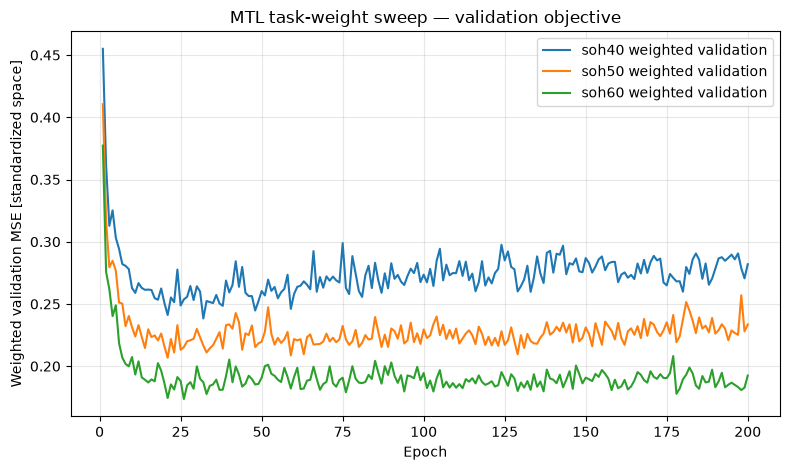

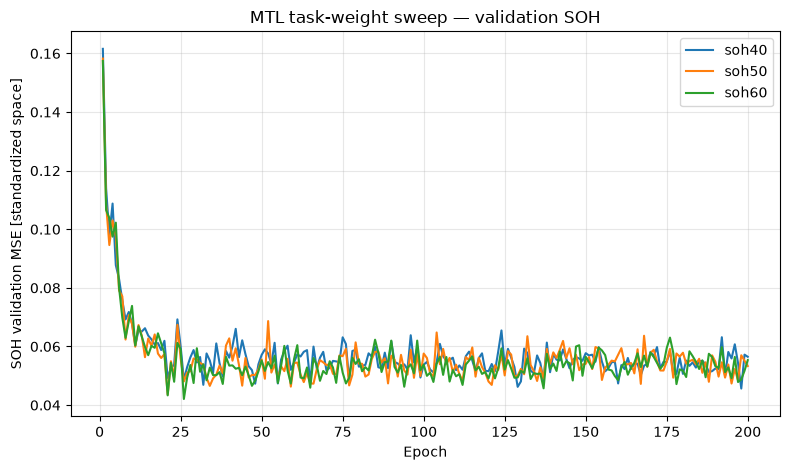

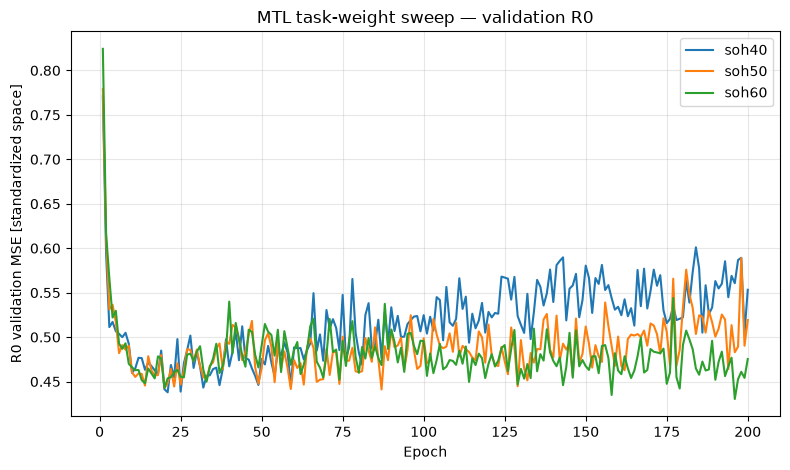

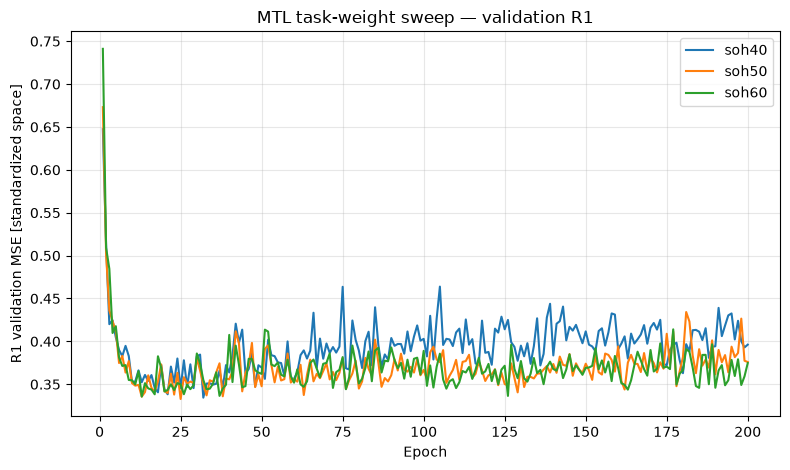

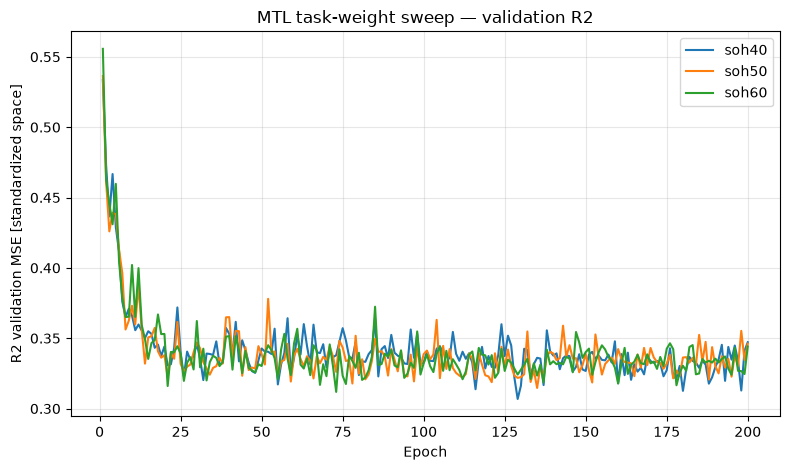

In [5]:
# ---- full 200-epoch weighted sweep: three configs x five seeds ----
def to_t(*arrays):
    return [torch.tensor(x).to(DEVICE) for x in arrays]

xtr, xttr, ytr, ymtr = to_t(Xtr, Xttr, Ytr, Ymtr)
xva, xtva, yva, ymva = to_t(Xva, Xtva, Yva, Ymva)
xte, xtte, yte, ymte = to_t(Xte, Xtte, Yte, Ymte)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def exact_multitask_losses_in_batches(
    model, x, xt, y, ym, task_weights, batch_size=256
):
    """
    Exact dataset-level losses using the same hierarchy as training:
      channel masked MSE
      -> equal mean within each task
      -> weighted mean across SOH/R0/R1/R2.

    Returns:
      weighted_total, unweighted_total, task_parts
    """
    model.eval()

    task_sse = {
        task: torch.zeros(
            len(idxs), dtype=torch.float64, device=DEVICE
        )
        for task, idxs in TASK_CHANNELS.items()
    }
    task_n = {
        task: torch.zeros(
            len(idxs), dtype=torch.float64, device=DEVICE
        )
        for task, idxs in TASK_CHANNELS.items()
    }

    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i+batch_size]
            xtb = xt[i:i+batch_size]
            yb = y[i:i+batch_size]
            mb = ym[i:i+batch_size]

            outputs = model(xb, xtb)

            for task, idxs in TASK_CHANNELS.items():
                target = yb[:, :, idxs]
                mask = mb[:, :, idxs].float()
                pred = outputs[task]

                task_sse[task] += (
                    (((pred - target) ** 2) * mask)
                    .sum(dim=(0, 1))
                    .double()
                )
                task_n[task] += mask.sum(dim=(0, 1)).double()

    parts = {}
    for task in TASK_ORDER:
        active = task_n[task] > 0
        if not torch.any(active):
            parts[task] = np.nan
        else:
            channel_mse = (
                task_sse[task][active] /
                task_n[task][active]
            )
            parts[task] = float(channel_mse.mean().item())

    active_tasks = [
        task for task in TASK_ORDER
        if np.isfinite(parts[task])
    ]
    if not active_tasks:
        raise RuntimeError('No valid tasks in dataset-level evaluation.')

    active_weight_sum = sum(float(task_weights[t]) for t in active_tasks)
    weighted_total = sum(
        (float(task_weights[t]) / active_weight_sum) * parts[t]
        for t in active_tasks
    )
    unweighted_total = float(np.mean([parts[t] for t in active_tasks]))

    return float(weighted_total), unweighted_total, parts

def clone_state_to_cpu(model):
    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }

def make_mtl_model():
    return MTLGRUSeq2Seq(
        F,
        hid=HID,
        layers=ENC_LAYERS,
        task_dims=TASK_DIMS,
        horizon=HORIZON,
        p=DROPOUT
    ).to(DEVICE)

def checkpoint_path(config_name, seed, kind):
    if kind not in {'joint', 'soh'}:
        raise ValueError("kind must be 'joint' or 'soh'")
    return CKPT_ROOT / config_name / f'seed_{seed}_best_{kind}.pt'

def train_one_seed(config_name, task_weights, seed):
    set_seed(seed)

    model = make_mtl_model()
    opt = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    config_dir = CKPT_ROOT / config_name
    config_dir.mkdir(parents=True, exist_ok=True)

    # PRIMARY checkpoint: lowest WEIGHTED validation joint loss.
    best_joint = math.inf
    best_joint_epoch = None
    best_joint_state = None
    best_joint_parts = None
    best_joint_unweighted = None

    # Diagnostic task-specific validation minima.
    best_task = {task: math.inf for task in TASK_ORDER}
    best_task_epoch = {task: None for task in TASK_ORDER}
    best_soh_state = None

    history = []
    N = len(xtr)

    # IMPORTANT: no early-stopping break; always run epochs 1..200.
    for ep in range(1, EPOCHS + 1):
        model.train()
        perm = torch.randperm(N)

        for i in range(0, N, BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]

            opt.zero_grad()
            outputs = model(xtr[idx], xttr[idx])
            loss, _ = multitask_loss(
                outputs,
                ytr[idx],
                ymtr[idx],
                task_weights
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # Epoch-end deterministic evaluation with dropout disabled.
        train_total, train_unweighted, train_parts = exact_multitask_losses_in_batches(
            model, xtr, xttr, ytr, ymtr,
            task_weights,
            batch_size=TRAIN_EVAL_BATCH
        )
        val_total, val_unweighted, val_parts = exact_multitask_losses_in_batches(
            model, xva, xtva, yva, ymva,
            task_weights,
            batch_size=TRAIN_EVAL_BATCH
        )

        # ---- primary weighted-joint checkpoint ----
        joint_improved = val_total < best_joint - 1e-6
        if joint_improved:
            best_joint = val_total
            best_joint_epoch = ep
            best_joint_state = clone_state_to_cpu(model)
            best_joint_parts = dict(val_parts)
            best_joint_unweighted = val_unweighted

        # ---- task-specific diagnostic minima ----
        task_improved = {}
        for task in TASK_ORDER:
            improved = (
                np.isfinite(val_parts[task]) and
                val_parts[task] < best_task[task] - 1e-6
            )
            task_improved[task] = bool(improved)

            if improved:
                best_task[task] = val_parts[task]
                best_task_epoch[task] = ep

                if task == 'SOH':
                    best_soh_state = clone_state_to_cpu(model)

        row = {
            'weight_config': config_name,
            'seed': seed,
            'epoch': ep,
            'train_total_MSE_std': train_total,  # weighted
            'val_total_MSE_std': val_total,      # weighted
            'train_unweighted_total_MSE_std': train_unweighted,
            'val_unweighted_total_MSE_std': val_unweighted,
            'is_best_joint_so_far': bool(joint_improved),
            **{f'w_{task}': float(task_weights[task]) for task in TASK_ORDER},
        }

        for task in TASK_ORDER:
            row[f'train_{task}_MSE_std'] = train_parts[task]
            row[f'val_{task}_MSE_std'] = val_parts[task]
            row[f'is_best_{task}_so_far'] = task_improved[task]

        history.append(row)

        if ep == 1 or ep % 20 == 0 or ep == EPOCHS:
            print(
                f"config={config_name} | seed={seed} | epoch={ep:3d}/{EPOCHS} "
                f"| weighted val={val_total:.6f} "
                f"| unweighted val={val_unweighted:.6f} "
                f"| SOH={val_parts['SOH']:.6f} "
                f"| R0={val_parts['R0']:.6f} "
                f"| R1={val_parts['R1']:.6f} "
                f"| R2={val_parts['R2']:.6f} "
                f"| best weighted joint={best_joint:.6f} @ {best_joint_epoch}"
            )

    if best_joint_state is None or best_soh_state is None:
        raise RuntimeError('A required checkpoint state was not captured.')

    joint_path = checkpoint_path(config_name, seed, 'joint')
    soh_path = checkpoint_path(config_name, seed, 'soh')
    torch.save(best_joint_state, joint_path)
    torch.save(best_soh_state, soh_path)

    info = {
        'weight_config': config_name,
        'seed': seed,
        **{f'w_{task}': float(task_weights[task]) for task in TASK_ORDER},
        'best_val_joint_MSE_std': best_joint,  # weighted joint criterion
        'best_val_weighted_joint_MSE_std': best_joint,
        'best_val_unweighted_joint_MSE_std_at_joint_ckpt': best_joint_unweighted,
        'best_joint_epoch': best_joint_epoch,
        'epochs_trained': EPOCHS,
        'joint_checkpoint_file': str(joint_path),
        'soh_checkpoint_file': str(soh_path),
    }

    for task in TASK_ORDER:
        info[f'joint_ckpt_val_{task}_MSE_std'] = best_joint_parts[task]

    for task in TASK_ORDER:
        info[f'best_val_{task}_MSE_std_diagnostic'] = best_task[task]
        info[f'best_{task}_epoch_diagnostic'] = best_task_epoch[task]

    return info, history

summary_csv = Path(f'{SWEEP_PREFIX}_training_summary_5seeds.csv')
history_csv = Path(f'{SWEEP_PREFIX}_training_history_5seeds.csv')

if RUN_SWEEP:
    training_rows = []
    history_rows = []

    for config_name, task_weights in WEIGHT_CONFIGS.items():
        print('\n' + '=' * 80)
        print('START CONFIG:', config_name, task_weights)
        print('=' * 80)

        for seed in SEEDS:
            info, hist = train_one_seed(
                config_name,
                task_weights,
                seed
            )
            training_rows.append(info)
            history_rows.extend(hist)

            print(
                f"FINAL config={config_name} | seed={seed} "
                f"| weighted joint={info['best_val_joint_MSE_std']:.6f} "
                f"@ {info['best_joint_epoch']} "
                f"| SOH-best={info['best_val_SOH_MSE_std_diagnostic']:.6f} "
                f"@ {info['best_SOH_epoch_diagnostic']}"
            )

    training_summary = pd.DataFrame(training_rows)
    training_history = pd.DataFrame(history_rows)

    training_summary.to_csv(summary_csv, index=False)
    training_history.to_csv(history_csv, index=False)

    print('\nSaved sweep training files:')
    print(summary_csv)
    print(history_csv)

else:
    if not summary_csv.exists() or not history_csv.exists():
        raise FileNotFoundError(
            'RUN_SWEEP=False but saved sweep CSVs were not found. '
            'Run Stage A once with RUN_SWEEP=True first.'
        )

    training_summary = pd.read_csv(summary_csv)
    training_history = pd.read_csv(history_csv)

    print('Loaded existing sweep training files:')
    print(summary_csv)
    print(history_csv)

display(training_summary.round(6))

# Compact training-history plots: five-seed mean validation curves.
mean_history = (
    training_history
    .groupby(['weight_config', 'epoch'], as_index=False)
    .agg(
        val_weighted_mean=('val_total_MSE_std', 'mean'),
        val_weighted_std=('val_total_MSE_std', 'std'),
        val_unweighted_mean=('val_unweighted_total_MSE_std', 'mean'),
        val_unweighted_std=('val_unweighted_total_MSE_std', 'std'),
        **{
            f'val_{task}_mean': (f'val_{task}_MSE_std', 'mean')
            for task in TASK_ORDER
        }
    )
)

plt.figure(figsize=(8, 4.8))
for config_name in WEIGHT_CONFIGS:
    d = mean_history[mean_history['weight_config'] == config_name]
    plt.plot(
        d['epoch'],
        d['val_weighted_mean'],
        label=f'{config_name} weighted validation'
    )
plt.xlabel('Epoch')
plt.ylabel('Weighted validation MSE [standardized space]')
plt.title('MTL task-weight sweep — validation objective')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for task in TASK_ORDER:
    plt.figure(figsize=(8, 4.8))
    for config_name in WEIGHT_CONFIGS:
        d = mean_history[mean_history['weight_config'] == config_name]
        plt.plot(
            d['epoch'],
            d[f'val_{task}_mean'],
            label=config_name
        )
    plt.xlabel('Epoch')
    plt.ylabel(f'{task} validation MSE [standardized space]')
    plt.title(f'MTL task-weight sweep — validation {task}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
# ======================================================================
# STAGE A: VALIDATION-ONLY WEIGHT COMPARISON
# ======================================================================
# Do not use test metrics here.
#
# Each candidate is first represented by its own weighted-joint-best
# checkpoint. We then compare the four task losses at that checkpoint
# against the frozen equal-weight MTL validation reference, seed by seed.
#
# ratio < 1  -> candidate improved relative to equal-weight MTL
# ratio > 1  -> candidate worsened relative to equal-weight MTL

base = FROZEN_EQUAL_VAL_BY_SEED.rename(
    columns={task: f'baseline_{task}' for task in TASK_ORDER}
)

val_compare = training_summary.merge(
    base,
    on='seed',
    how='left',
    validate='many_to_one'
)

for task in TASK_ORDER:
    cand_col = f'joint_ckpt_val_{task}_MSE_std'
    base_col = f'baseline_{task}'
    val_compare[f'{task}_ratio_to_equal'] = (
        val_compare[cand_col] / val_compare[base_col]
    )
    val_compare[f'{task}_change_pct_vs_equal'] = (
        (val_compare[f'{task}_ratio_to_equal'] - 1.0) * 100.0
    )

ratio_cols = [f'{task}_ratio_to_equal' for task in TASK_ORDER]
val_compare['balanced_four_task_ratio'] = val_compare[ratio_cols].mean(axis=1)
val_compare['resistance_mean_ratio'] = val_compare[
    [f'{task}_ratio_to_equal' for task in ['R0', 'R1', 'R2']]
].mean(axis=1)
val_compare['resistance_worst_ratio'] = val_compare[
    [f'{task}_ratio_to_equal' for task in ['R0', 'R1', 'R2']]
].max(axis=1)

selection_rows = []
for config_name, d in val_compare.groupby('weight_config', sort=False):
    row = {
        'weight_config': config_name,
        'w_SOH': d['w_SOH'].iloc[0],
        'w_R0': d['w_R0'].iloc[0],
        'w_R1': d['w_R1'].iloc[0],
        'w_R2': d['w_R2'].iloc[0],
        'N seeds': d['seed'].nunique(),
        'best_joint_epoch_mean': d['best_joint_epoch'].mean(),
        'best_joint_epoch_std': d['best_joint_epoch'].std(ddof=1),
        'balanced_four_task_ratio_mean': d['balanced_four_task_ratio'].mean(),
        'balanced_four_task_ratio_std': d['balanced_four_task_ratio'].std(ddof=1),
        'resistance_mean_ratio_mean': d['resistance_mean_ratio'].mean(),
        'resistance_worst_ratio_mean': d['resistance_worst_ratio'].mean(),
    }

    for task in TASK_ORDER:
        ratio = d[f'{task}_ratio_to_equal']
        row[f'{task}_ratio_to_equal_mean'] = ratio.mean()
        row[f'{task}_ratio_to_equal_std'] = ratio.std(ddof=1)
        row[f'{task}_change_pct_vs_equal_mean'] = (ratio.mean() - 1.0) * 100.0

    selection_rows.append(row)

validation_selection = (
    pd.DataFrame(selection_rows)
    .sort_values('balanced_four_task_ratio_mean')
    .reset_index(drop=True)
)

# Add the frozen equal-weight reference as a visual anchor.
baseline_anchor = {
    'weight_config': 'equal25_frozen',
    'w_SOH': 0.25,
    'w_R0': 0.25,
    'w_R1': 0.25,
    'w_R2': 0.25,
    'N seeds': len(SEEDS),
    'best_joint_epoch_mean': np.nan,
    'best_joint_epoch_std': np.nan,
    'balanced_four_task_ratio_mean': 1.0,
    'balanced_four_task_ratio_std': 0.0,
    'resistance_mean_ratio_mean': 1.0,
    'resistance_worst_ratio_mean': 1.0,
}
for task in TASK_ORDER:
    baseline_anchor[f'{task}_ratio_to_equal_mean'] = 1.0
    baseline_anchor[f'{task}_ratio_to_equal_std'] = 0.0
    baseline_anchor[f'{task}_change_pct_vs_equal_mean'] = 0.0

validation_selection_with_baseline = pd.concat(
    [pd.DataFrame([baseline_anchor]), validation_selection],
    ignore_index=True
)

selection_per_seed_csv = Path(
    f'{SWEEP_PREFIX}_validation_comparison_per_seed.csv'
)
selection_summary_csv = Path(
    f'{SWEEP_PREFIX}_validation_weight_selection.csv'
)

val_compare.to_csv(selection_per_seed_csv, index=False)
validation_selection_with_baseline.to_csv(
    selection_summary_csv,
    index=False
)

print('Validation-only weight comparison:')
display_cols = [
    'weight_config',
    'w_SOH', 'w_R0', 'w_R1', 'w_R2',
    'SOH_change_pct_vs_equal_mean',
    'R0_change_pct_vs_equal_mean',
    'R1_change_pct_vs_equal_mean',
    'R2_change_pct_vs_equal_mean',
    'balanced_four_task_ratio_mean',
    'resistance_worst_ratio_mean',
]
display(
    validation_selection_with_baseline[display_cols]
    .round(4)
)

print('\nSaved validation-only selection files:')
print(selection_per_seed_csv)
print(selection_summary_csv)

print(
    '\nIMPORTANT: keep FINAL_CONFIG=None until one weight setting is fixed '
    'from this validation-only table. Test evaluation is intentionally '
    'skipped while FINAL_CONFIG is None.'
)

Validation-only weight comparison:


,weight_config,w_SOH,w_R0,w_R1,w_R2,SOH_change_pct_vs_equal_mean,R0_change_pct_vs_equal_mean,R1_change_pct_vs_equal_mean,R2_change_pct_vs_equal_mean,balanced_four_task_ratio_mean,resistance_worst_ratio_mean
0,equal25_frozen,0.25,0.2500,0.2500,0.2500,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
1,soh50,0.50,0.1667,0.1667,0.1667,-13.4971,4.1232,1.1615,-4.4778,0.9683,1.0541
2,soh60,0.60,0.1333,0.1333,0.1333,-9.6651,4.4869,-1.1615,-4.6621,0.9725,1.1031
3,soh40,0.40,0.2000,0.2000,0.2000,1.6683,2.8853,2.7057,1.4267,1.0217,1.1247



Saved validation-only selection files:
mtl_gru_4task_full200_weight_sweep_validation_comparison_per_seed.csv
mtl_gru_4task_full200_weight_sweep_validation_weight_selection.csv

IMPORTANT: keep FINAL_CONFIG=None until one weight setting is fixed from this validation-only table. Test evaluation is intentionally skipped while FINAL_CONFIG is None.


In [7]:
# ---- evaluation helpers retained from the previous full-200 notebook ----
def predict_full(model, x, xt):
    model.eval()
    with torch.no_grad():
        outputs = model(x, xt)

    pred = np.full(
        (len(x), HORIZON, F),
        np.nan,
        dtype=np.float32
    )

    for task, idxs in TASK_CHANNELS.items():
        pred[:, :, idxs] = outputs[task].cpu().numpy()

    return pred

def r2_score_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_pred - y_true) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

def build_point_table(weight_config, seed, split, pred_std, Y, Ym, bid):
    rows = []

    for j, component in enumerate(features):
        task = FEATURE_TO_TASK[component]

        for i in range(len(Y)):
            hs = np.flatnonzero(Ym[i, :, j])
            if len(hs) == 0:
                continue

            yt_std = Y[i, hs, j].astype(float)
            yp_std = pred_std[i, hs, j].astype(float)

            yt_phys = inverse_feature(yt_std, j)
            yp_phys = inverse_feature(yp_std, j)

            for k, h in enumerate(hs):
                denom = max(abs(float(yt_phys[k])), 1e-12)

                rows.append({
                    'weight_config': weight_config,
                    'seed': seed,
                    'split': split,
                    'bid': int(bid[i]),
                    'task': task,
                    'component': component,
                    'horizon': int(h) + 1,
                    'yt_std': float(yt_std[k]),
                    'yp_std': float(yp_std[k]),
                    'yt_phys': float(yt_phys[k]),
                    'yp_phys': float(yp_phys[k]),
                    'abs_std': abs(float(yp_std[k] - yt_std[k])),
                    'sq_std': float((yp_std[k] - yt_std[k]) ** 2),
                    'abs_phys': abs(float(yp_phys[k] - yt_phys[k])),
                    'sq_phys': float((yp_phys[k] - yt_phys[k]) ** 2),
                    'ape_phys': abs(float(yp_phys[k] - yt_phys[k])) / denom * 100.0,
                })

    return pd.DataFrame(rows)

def component_metrics_from_points(df):
    rows = []

    for (weight_config, seed, split, task, component), d in df.groupby(
        ['weight_config', 'seed', 'split', 'task', 'component'],
        sort=False
    ):
        per_cell = (
            d.groupby('bid')
             .agg(
                 mae_std=('abs_std', 'mean'),
                 mae_phys=('abs_phys', 'mean'),
                 mape_phys=('ape_phys', 'mean'),
             )
        )

        rows.append({
            'weight_config': weight_config,
            'seed': seed,
            'split': split,
            'task': task,
            'component': component,

            'MAE macro [std]': per_cell['mae_std'].mean(),
            'MAE pooled [std]': d['abs_std'].mean(),
            'RMSE pooled [std]': math.sqrt(d['sq_std'].mean()),
            'R2 pooled [std]': r2_score_np(d['yt_std'], d['yp_std']),

            'MAE macro [physical]': per_cell['mae_phys'].mean(),
            'MAE pooled [physical]': d['abs_phys'].mean(),
            'RMSE pooled [physical]': math.sqrt(d['sq_phys'].mean()),
            'R2 pooled [physical]': r2_score_np(d['yt_phys'], d['yp_phys']),
            'MAPE macro [%]': per_cell['mape_phys'].mean(),

            'N cells': int(d['bid'].nunique()),
            'N points': int(len(d)),
        })

    return pd.DataFrame(rows)

metric_cols = [
    'MAE macro [std]',
    'MAE pooled [std]',
    'RMSE pooled [std]',
    'R2 pooled [std]',
    'MAE macro [physical]',
    'MAE pooled [physical]',
    'RMSE pooled [physical]',
    'R2 pooled [physical]',
    'MAPE macro [%]',
]

def load_checkpoint_model(config_name, seed, kind='joint'):
    path = checkpoint_path(config_name, seed, kind)
    if not path.exists():
        raise FileNotFoundError(
            f'Checkpoint not found: {path}. '
            'Run Stage A first or check CKPT_ROOT.'
        )

    model = make_mtl_model()
    try:
        state = torch.load(
            path,
            map_location=DEVICE,
            weights_only=True
        )
    except TypeError:
        state = torch.load(
            path,
            map_location=DEVICE
        )
    model.load_state_dict(state)
    return model

In [8]:
# ======================================================================
# STAGE B: FINAL CONFIG ONLY — validation + test evaluation
# ======================================================================
# This cell intentionally does nothing while FINAL_CONFIG is None.
#
# After fixing the weight setting from Stage A, set for example:
# FINAL_CONFIG = 'soh40'
# in the settings cell, then run from the settings/data/model cells onward.
#
# Do NOT change FINAL_CONFIG after inspecting test performance.

if FINAL_CONFIG is None:
    points_all = pd.DataFrame()
    component_metrics = pd.DataFrame()
    component_summary = pd.DataFrame()
    task_metrics = pd.DataFrame()
    task_summary = pd.DataFrame()
    soh_diag_points = pd.DataFrame()
    soh_diag_metrics = pd.DataFrame()
    soh_diag_summary = pd.DataFrame()
    soh_checkpoint_comparison_per_seed = pd.DataFrame()
    soh_checkpoint_comparison_summary = pd.DataFrame()

    print(
        'FINAL_CONFIG=None -> test evaluation skipped by design. '
        'Choose one config using Stage A validation only.'
    )

else:
    if FINAL_CONFIG not in WEIGHT_CONFIGS:
        raise ValueError(
            f'FINAL_CONFIG must be one of {list(WEIGHT_CONFIGS)}'
        )

    final_weights = WEIGHT_CONFIGS[FINAL_CONFIG]
    print('FINAL CONFIG:', FINAL_CONFIG, final_weights)

    point_tables = []

    for seed in SEEDS:
        model = load_checkpoint_model(
            FINAL_CONFIG,
            seed,
            kind='joint'
        )

        pred_val = predict_full(model, xva, xtva)
        pred_test = predict_full(model, xte, xtte)

        point_tables.append(
            build_point_table(
                FINAL_CONFIG, seed, 'val',
                pred_val, Yva, Ymva, bva
            )
        )
        point_tables.append(
            build_point_table(
                FINAL_CONFIG, seed, 'test',
                pred_test, Yte, Ymte, bte
            )
        )

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    points_all = pd.concat(point_tables, ignore_index=True)

    # ---- detailed 10-component metrics ----
    component_metrics = component_metrics_from_points(points_all)

    # ---- main 4-task metrics: equal mean over components inside each task ----
    task_metrics = (
        component_metrics
        .groupby(
            ['weight_config', 'seed', 'split', 'task'],
            as_index=False
        )[metric_cols]
        .mean()
    )

    task_metrics['unit'] = task_metrics['task'].map({
        'SOH': '%SOH',
        'R0': 'R original unit',
        'R1': 'R original unit',
        'R2': 'R original unit',
    })

    # ---- five-seed task summary ----
    task_summary_rows = []
    for (weight_config, split, task), d in task_metrics.groupby(
        ['weight_config', 'split', 'task'],
        sort=False
    ):
        row = {
            'weight_config': weight_config,
            'split': split,
            'task': task,
            'unit': d['unit'].iloc[0],
            'N seeds': d['seed'].nunique(),
        }
        for col in metric_cols:
            row[f'{col} mean'] = d[col].mean()
            row[f'{col} std'] = d[col].std(ddof=1)
        task_summary_rows.append(row)

    task_summary = pd.DataFrame(task_summary_rows)

    # ---- five-seed component summary ----
    component_summary_rows = []
    for (weight_config, split, task, component), d in component_metrics.groupby(
        ['weight_config', 'split', 'task', 'component'],
        sort=False
    ):
        row = {
            'weight_config': weight_config,
            'split': split,
            'task': task,
            'component': component,
            'N seeds': d['seed'].nunique(),
            'N cells': int(round(d['N cells'].mean())),
            'N points': int(round(d['N points'].mean())),
        }
        for col in metric_cols:
            row[f'{col} mean'] = d[col].mean()
            row[f'{col} std'] = d[col].std(ddof=1)
        component_summary_rows.append(row)

    component_summary = pd.DataFrame(component_summary_rows)

    print('FINAL weighted MTL test results — five-seed mean ± std:')
    main_test_cols = [
        'weight_config',
        'task', 'unit',
        'MAE macro [physical] mean', 'MAE macro [physical] std',
        'RMSE pooled [physical] mean', 'RMSE pooled [physical] std',
        'MAPE macro [%] mean', 'MAPE macro [%] std',
        'R2 pooled [physical] mean', 'R2 pooled [physical] std',
    ]
    display(
        task_summary[
            task_summary['split'] == 'test'
        ][main_test_cols]
        .round(4)
        .reset_index(drop=True)
    )

    print('\nDetailed final test component results:')
    component_test_cols = [
        'weight_config',
        'task', 'component',
        'MAE macro [physical] mean', 'MAE macro [physical] std',
        'RMSE pooled [physical] mean', 'RMSE pooled [physical] std',
        'MAPE macro [%] mean', 'MAPE macro [%] std',
        'R2 pooled [physical] mean', 'R2 pooled [physical] std',
        'N cells', 'N points',
    ]
    display(
        component_summary[
            component_summary['split'] == 'test'
        ][component_test_cols]
        .round(4)
        .reset_index(drop=True)
    )

    # --------------------------------------------------------------
    # SOH-BEST CHECKPOINT DIAGNOSTIC FOR THE ALREADY-FIXED CONFIG
    # --------------------------------------------------------------
    soh_diag_point_tables = []

    for seed in SEEDS:
        diag_model = load_checkpoint_model(
            FINAL_CONFIG,
            seed,
            kind='soh'
        )

        pred_val_sohbest = predict_full(diag_model, xva, xtva)
        pred_test_sohbest = predict_full(diag_model, xte, xtte)

        dv = build_point_table(
            FINAL_CONFIG, seed, 'val',
            pred_val_sohbest, Yva, Ymva, bva
        )
        dt = build_point_table(
            FINAL_CONFIG, seed, 'test',
            pred_test_sohbest, Yte, Ymte, bte
        )

        dv = dv[dv['task'] == 'SOH'].copy()
        dt = dt[dt['task'] == 'SOH'].copy()
        dv['checkpoint'] = 'best_val_SOH'
        dt['checkpoint'] = 'best_val_SOH'

        soh_diag_point_tables.extend([dv, dt])

        del diag_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    soh_diag_points = pd.concat(
        soh_diag_point_tables,
        ignore_index=True
    )

    soh_diag_metrics = component_metrics_from_points(
        soh_diag_points
    )
    soh_diag_metrics['checkpoint'] = 'best_val_SOH'
    soh_diag_metrics['unit'] = '%SOH'

    soh_diag_summary_rows = []
    for (weight_config, split), d in soh_diag_metrics.groupby(
        ['weight_config', 'split'],
        sort=False
    ):
        row = {
            'weight_config': weight_config,
            'split': split,
            'task': 'SOH',
            'checkpoint': 'best_val_SOH',
            'unit': '%SOH',
            'N seeds': d['seed'].nunique(),
        }
        for col in metric_cols:
            row[f'{col} mean'] = d[col].mean()
            row[f'{col} std'] = d[col].std(ddof=1)
        soh_diag_summary_rows.append(row)

    soh_diag_summary = pd.DataFrame(
        soh_diag_summary_rows
    )

    joint_soh_per_seed = (
        task_metrics[
            task_metrics['task'] == 'SOH'
        ][
            ['weight_config', 'seed', 'split'] + metric_cols
        ]
        .copy()
    )
    joint_soh_per_seed['checkpoint'] = 'best_val_joint'

    diag_soh_per_seed = (
        soh_diag_metrics[
            ['weight_config', 'seed', 'split'] + metric_cols
        ]
        .copy()
    )
    diag_soh_per_seed['checkpoint'] = 'best_val_SOH'

    soh_checkpoint_comparison_per_seed = pd.concat(
        [joint_soh_per_seed, diag_soh_per_seed],
        ignore_index=True
    )

    comparison_rows = []
    for (weight_config, split, checkpoint), d in (
        soh_checkpoint_comparison_per_seed.groupby(
            ['weight_config', 'split', 'checkpoint'],
            sort=False
        )
    ):
        row = {
            'weight_config': weight_config,
            'split': split,
            'checkpoint': checkpoint,
            'N seeds': d['seed'].nunique(),
        }
        for col in metric_cols:
            row[f'{col} mean'] = d[col].mean()
            row[f'{col} std'] = d[col].std(ddof=1)
        comparison_rows.append(row)

    soh_checkpoint_comparison_summary = pd.DataFrame(
        comparison_rows
    )

    print(
        '\nSOH checkpoint comparison for the already-fixed final weight config:'
    )
    display(
        soh_checkpoint_comparison_summary[
            soh_checkpoint_comparison_summary['split'] == 'test'
        ][
            [
                'weight_config',
                'checkpoint',
                'MAE macro [physical] mean',
                'MAE macro [physical] std',
                'RMSE pooled [physical] mean',
                'RMSE pooled [physical] std',
                'R2 pooled [physical] mean',
                'R2 pooled [physical] std',
            ]
        ].round(4).reset_index(drop=True)
    )

FINAL_CONFIG=None -> test evaluation skipped by design. Choose one config using Stage A validation only.


In [9]:
# ---- forecast-horizon analysis for FINAL_CONFIG only ----
if FINAL_CONFIG is None:
    horizon_summary = pd.DataFrame()
    print('Horizon analysis skipped because FINAL_CONFIG=None.')

else:
    test_points = points_all[
        points_all['split'] == 'test'
    ].copy()

    component_horizon = (
        test_points
        .groupby(
            ['weight_config', 'seed', 'task', 'component', 'horizon']
        )
        .agg(
            MAE_std=('abs_std', 'mean'),
            RMSE_std=('sq_std', lambda s: math.sqrt(s.mean())),
            MAE_phys=('abs_phys', 'mean'),
            RMSE_phys=('sq_phys', lambda s: math.sqrt(s.mean())),
            N=('yt_std', 'size'),
        )
        .reset_index()
    )

    task_horizon = (
        component_horizon
        .groupby(
            ['weight_config', 'seed', 'task', 'horizon']
        )
        .agg(
            MAE_std=('MAE_std', 'mean'),
            RMSE_std=('RMSE_std', 'mean'),
            MAE_phys=('MAE_phys', 'mean'),
            RMSE_phys=('RMSE_phys', 'mean'),
            N_component_min=('N', 'min'),
            N_component_max=('N', 'max'),
        )
        .reset_index()
    )

    horizon_rows = []
    for (weight_config, task, horizon), d in task_horizon.groupby(
        ['weight_config', 'task', 'horizon'],
        sort=False
    ):
        horizon_rows.append({
            'weight_config': weight_config,
            'task': task,
            'horizon': int(horizon),

            'MAE_std_mean': d['MAE_std'].mean(),
            'MAE_std_std': d['MAE_std'].std(ddof=1),
            'RMSE_std_mean': d['RMSE_std'].mean(),
            'RMSE_std_std': d['RMSE_std'].std(ddof=1),

            'MAE_phys_mean': d['MAE_phys'].mean(),
            'MAE_phys_std': d['MAE_phys'].std(ddof=1),
            'RMSE_phys_mean': d['RMSE_phys'].mean(),
            'RMSE_phys_std': d['RMSE_phys'].std(ddof=1),

            'N_component_min': int(d['N_component_min'].iloc[0]),
            'N_component_max': int(d['N_component_max'].iloc[0]),
        })

    horizon_summary = pd.DataFrame(horizon_rows)

    for task in TASK_ORDER:
        d = horizon_summary[
            horizon_summary['task'] == task
        ].sort_values('horizon')

        if d.empty:
            continue

        plt.figure(figsize=(7.5, 4.5))
        plt.plot(
            d['horizon'],
            d['MAE_phys_mean'],
            marker='o',
            label='MAE'
        )
        plt.fill_between(
            d['horizon'],
            d['MAE_phys_mean'] - d['MAE_phys_std'],
            d['MAE_phys_mean'] + d['MAE_phys_std'],
            alpha=0.2
        )
        plt.plot(
            d['horizon'],
            d['RMSE_phys_mean'],
            marker='s',
            label='RMSE'
        )
        plt.fill_between(
            d['horizon'],
            d['RMSE_phys_mean'] - d['RMSE_phys_std'],
            d['RMSE_phys_mean'] + d['RMSE_phys_std'],
            alpha=0.2
        )

        plt.xlabel('Forecast horizon')
        if task == 'SOH':
            plt.ylabel('Error [%SOH]')
        else:
            plt.ylabel('Resistance error [original unit]')

        plt.title(
            f'MTL-GRU {FINAL_CONFIG} {task} error vs forecast horizon'
        )
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    display(horizon_summary.round(4))

Horizon analysis skipped because FINAL_CONFIG=None.


In [10]:
# ---- save Stage B outputs only after FINAL_CONFIG has been frozen ----
if FINAL_CONFIG is None:
    print(
        'No final test files saved because FINAL_CONFIG=None. '
        'Stage A sweep/validation files were already saved.'
    )

else:
    prefix = f'mtl_gru_4task_full200_weighted_{FINAL_CONFIG}'

    points_all.to_csv(
        f'{prefix}_joint_predictions_5seeds.csv',
        index=False
    )
    component_metrics.to_csv(
        f'{prefix}_joint_component_metrics_per_seed.csv',
        index=False
    )
    component_summary.to_csv(
        f'{prefix}_joint_component_metrics_5seed_summary.csv',
        index=False
    )
    task_metrics.to_csv(
        f'{prefix}_joint_task_metrics_per_seed.csv',
        index=False
    )
    task_summary.to_csv(
        f'{prefix}_joint_task_metrics_5seed_summary.csv',
        index=False
    )
    horizon_summary.to_csv(
        f'{prefix}_joint_horizon_5seed_summary.csv',
        index=False
    )

    soh_diag_points.to_csv(
        f'{prefix}_sohbest_predictions_5seeds.csv',
        index=False
    )
    soh_diag_metrics.to_csv(
        f'{prefix}_sohbest_metrics_per_seed.csv',
        index=False
    )
    soh_diag_summary.to_csv(
        f'{prefix}_sohbest_metrics_5seed_summary.csv',
        index=False
    )
    soh_checkpoint_comparison_per_seed.to_csv(
        f'{prefix}_soh_checkpoint_comparison_per_seed.csv',
        index=False
    )
    soh_checkpoint_comparison_summary.to_csv(
        f'{prefix}_soh_checkpoint_comparison_5seed_summary.csv',
        index=False
    )

    final_meta = {
        'FINAL_CONFIG': FINAL_CONFIG,
        'weights': WEIGHT_CONFIGS[FINAL_CONFIG],
        'seeds': SEEDS,
        'epochs': EPOCHS,
        'checkpoint_rule': 'minimum weighted validation joint MSE',
        'weight_selection_rule': (
            'validation-only comparison to frozen equal-weight MTL'
        ),
    }
    with open(
        f'{prefix}_experiment_metadata.json',
        'w',
        encoding='utf-8'
    ) as f:
        json.dump(final_meta, f, indent=2)

    print('Saved final weighted-MTL outputs with prefix:')
    print(prefix)
    print('Checkpoint root:', CKPT_ROOT)

No final test files saved because FINAL_CONFIG=None. Stage A sweep/validation files were already saved.


## How to run this notebook

### First run — Stage A only

Keep:

```python
RUN_SWEEP = True
FINAL_CONFIG = None
```

Run the notebook through the validation-selection cell.

The most important files to inspect/share are:

- `mtl_gru_4task_full200_weight_sweep_training_summary_5seeds.csv`
- `mtl_gru_4task_full200_weight_sweep_validation_comparison_per_seed.csv`
- `mtl_gru_4task_full200_weight_sweep_validation_weight_selection.csv`

At this stage, **do not choose the weight using test results**. Test evaluation is disabled while `FINAL_CONFIG=None`.

### Second run — only after the weight has been fixed

Set:

```python
RUN_SWEEP = False
FINAL_CONFIG = 'soh40'   # example only
```

Then rerun the setup/data/model cells and the final evaluation cells.  
The notebook loads the saved checkpoint files, so the 200-epoch sweep does **not** need to be repeated.

### What changed relative to the previous equal-weight notebook

The architecture and all non-weight hyperparameters remain fixed.

The only methodological changes are:

1. the three SOH-heavy task-weight candidates;
2. the training loss now actually consumes `task_weights`;
3. the validation joint loss uses the same task weights;
4. the joint-best checkpoint is selected by that weighted validation loss;
5. the sweep is separated from final test evaluation to prevent test-driven tuning.